In [34]:
import torch
import torch.nn as nn
import math

In [35]:
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [36]:
class MultiheadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.d_model = d_model
        self.heads = heads
        self.kL = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )
        self.qL = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )
        self.vL = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )
        self.fc = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )

    def forward(self, x:torch.Tensor):
        K = self.kL(x)
        Q = self.qL(x)
        V = self.vL(x)
        # x is [batch_size, N, d_model]
        # convert it to [batch_size, N, heads, d_model/heads]
        # then transpose it to [batch_size, heads, N, d_model/heads]

        batch_size = x.shape[0]
        N = x.shape[1]

        K_divided_heads = K.reshape(batch_size, N, self.heads, -1)
        K_divided_heads = K_divided_heads.transpose(1, 2)
        Q_divided_heads = Q.reshape(batch_size, N, self.heads, -1)
        Q_divided_heads = Q_divided_heads.transpose(1, 2)
        V_divided_heads = V.reshape(batch_size, N, self.heads, -1)
        V_divided_heads = V_divided_heads.transpose(1, 2)

        energy = torch.matmul(Q_divided_heads, K_divided_heads.transpose(-1, -2))
        energy /= math.sqrt(self.d_model // self.heads)

        attn_weights = torch.softmax(energy, -1)
        attn = torch.matmul(attn_weights, V_divided_heads)
        attn = attn.transpose(1, 2).contiguous()
        attn = attn.view(batch_size, N, -1)
        return self.fc(attn), attn_weights

In [37]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.d_model = d_model
        self.heads = heads

        self.mha = MultiheadAttention(d_model, heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(
                in_features = d_model,
                out_features = d_model*2
            ),
            nn.Tanh(),
            nn.Linear(
                in_features = d_model*2,
                out_features = d_model
            )
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor):
        x_norm1 = self.norm1(x)
        x_atn, attn = self.mha(x_norm1)
        x = x + x_atn
        
        x_norm2 = self.norm2(x)
        x_ff = self.ff(x_norm2)
        x = x + x_ff

        return x, attn

In [38]:
import torch
import torch.nn as nn

class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # We create a Parameter instead of a buffer.
        # Shape: (1, max_len, d_model) -> The 1 is for batch broadcasting.
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x):
        # x shape: (Batch, Seq_Len, d_model)
        
        # We still slice it in case the input sequence is shorter than max_len
        x = x + self.pe[:, :x.size(1), :]
        
        return self.dropout(x)

In [39]:
class Encoder(nn.Module):
    def __init__(self, img_size, patch_size, d_model, heads, num_layers, device=DEVICE):
        super().__init__()
        self.device = device
        self.N = (img_size // patch_size) ** 2 + 1 
        self.d_model = d_model
        self.heads = heads
        self.num_layers = num_layers

        self.clsToken = nn.Parameter(torch.randn(1, 1, d_model))
        
        self.patch = nn.Conv2d(
            in_channels=3, 
            out_channels=d_model,
            kernel_size=patch_size,
            stride=patch_size
        )
        
        self.pos_encoding = LearnablePositionalEncoding(d_model, self.N)
        self.layerStack = nn.ModuleList([EncoderBlock(d_model, heads) for _ in range(num_layers)])
    def forward(self, x:torch.Tensor):
        #x is image of shape : [batch_size, channels=1, img_size, img_size]
        #after conv2d : [batch_size, d_model, N, N]
        batch_size = x.shape[0]
        x = self.patch(x)
        x = x.flatten(2, 3)
        x = x.transpose(1, 2)
        cls_token = self.clsToken.expand(batch_size, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        
        #now x is [batch_size, N^2 + 1, d_model]
        x = self.pos_encoding(x)
        attn_weights = torch.zeros(batch_size, self.num_layers, self.heads, self.N, self.N).to(self.device)
        for i, layer in enumerate(self.layerStack):
            x, attn = layer(x)
            attn_weights[:, i] = attn
        return x, attn_weights

In [40]:
class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, d_model, heads, num_layers, num_classes, device=DEVICE):
        super().__init__()
        self.encoder = Encoder(img_size, patch_size, d_model, heads, num_layers, device)
        self.classifier = nn.Linear(
            in_features=d_model,
            out_features=num_classes
        )

    def forward(self, x):
        x, attn = self.encoder(x)
        x = self.classifier(x[:, 0, :])
        return x, attn

In [41]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from tqdm import tqdm

In [42]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [43]:
train_dataset = datasets.STL10(
    root="./dataset_stl",
    split='train',
    download=True,
    transform=train_transform
)

# Testing Dataset
test_dataset = datasets.STL10(
    root="./dataset_stl",
    split='test',
    download=True,
    transform=test_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [44]:
classes = train_dataset.classes
classes

['airplane',
 'bird',
 'car',
 'cat',
 'deer',
 'dog',
 'horse',
 'monkey',
 'ship',
 'truck']

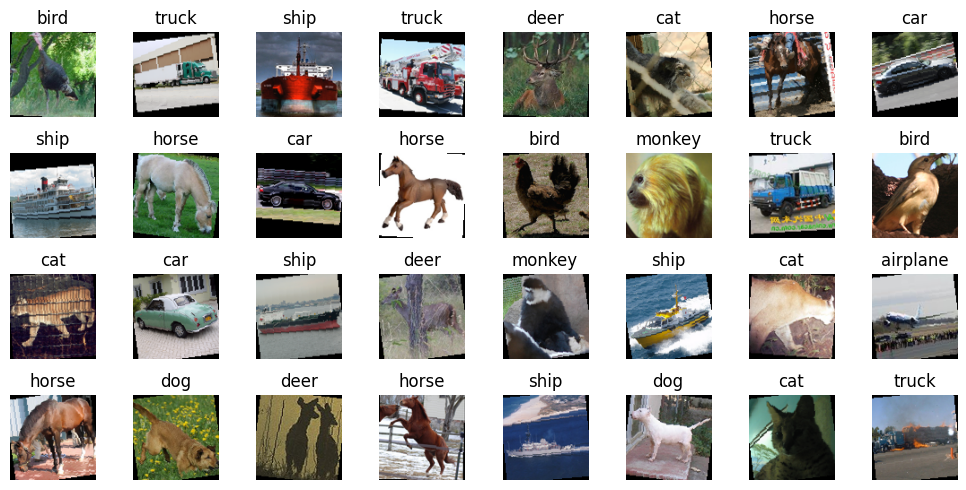

In [45]:
images, labels = next(iter(train_dataloader))

plt.figure(figsize=(10, 5))

for i in range(32):
    plt.subplot(4, 8, i + 1)
    img = images[i].cpu().squeeze().permute(1,2,0).numpy()
    img = img / 2 + 0.5
    plt.imshow(img)
    plt.title(f"{classes[labels[i].item()]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [46]:
#hyper parameters
img_size = 96
patch_size = 8
d_model = 384
num_heads = 12
num_layers = 4
num_classes = len(classes)

model = VisionTransformer(img_size, patch_size, d_model, num_heads, num_layers, num_classes, DEVICE)
model.load_state_dict(torch.load('weights/ViT_STL10.pt'))
model = model.to(DEVICE)

In [47]:
img, label = next(iter(train_dataloader))
img = img.to(DEVICE)
preds, attn = model(img)
preds.shape, attn.shape

(torch.Size([32, 10]), torch.Size([32, 4, 12, 145, 145]))

In [48]:
def trainer(model, LR, EPOCHS, dataloader):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(params=model.parameters(), lr=LR)
    
    model.train()

    for epoch in range(EPOCHS):
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True) 
        total_loss = 0
        total_correct = 0
        total_samples = 0

        for images, labels in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            preds, _ = model(images)
            loss = loss_fn(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred_labels = torch.argmax(preds, dim=1)
            
            total_correct += (pred_labels == labels).sum().item()
            total_samples += labels.size(0)
            
            batch_acc = (pred_labels == labels).sum().item() / labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=f"{batch_acc:.2%}")
        
        avg_loss = total_loss / len(dataloader)
        final_acc = (total_correct / total_samples) * 100

        print(f"\nEpoch {epoch+1} Finished | Avg Loss = {avg_loss:.5f} | Avg Accuracy = {final_acc:.2f}%\n")
        
        torch.save(model.state_dict(), 'weights/ViT_STL10.pt')

In [49]:
def tester(model, dataloader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            preds, _ = model(images)
            loss = loss_fn(preds, labels)

            total_loss += loss.item()
            pred_labels = torch.argmax(preds, dim=1)
            total_correct += (pred_labels == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    final_acc = (total_correct / total_samples) * 100

    print(f"\nTest Results | Avg Loss = {avg_loss:.5f} | Avg Accuracy = {final_acc:.2f}%\n")    

In [55]:
trainer(model, 1e-5, 50, train_dataloader)
tester(model, test_dataloader)

Epoch 1/50: 100%|██████████| 157/157 [00:23<00:00,  6.79it/s, acc=87.50%, loss=0.528]



Epoch 1 Finished | Avg Loss = 0.88121 | Avg Accuracy = 67.60%



Epoch 2/50: 100%|██████████| 157/157 [00:23<00:00,  6.78it/s, acc=87.50%, loss=0.575]



Epoch 2 Finished | Avg Loss = 0.89477 | Avg Accuracy = 67.48%



Epoch 3/50: 100%|██████████| 157/157 [00:24<00:00,  6.32it/s, acc=37.50%, loss=1.84] 


...


Epoch 48 Finished | Avg Loss = 0.73414 | Avg Accuracy = 73.00%



Epoch 49/50: 100%|██████████| 157/157 [00:33<00:00,  4.73it/s, acc=87.50%, loss=0.266]



Epoch 49 Finished | Avg Loss = 0.71048 | Avg Accuracy = 73.46%



Epoch 50/50: 100%|██████████| 157/157 [00:33<00:00,  4.74it/s, acc=75.00%, loss=0.48] 



Epoch 50 Finished | Avg Loss = 0.73667 | Avg Accuracy = 73.86%


Test Results | Avg Loss = 1.41514 | Avg Accuracy = 53.79%



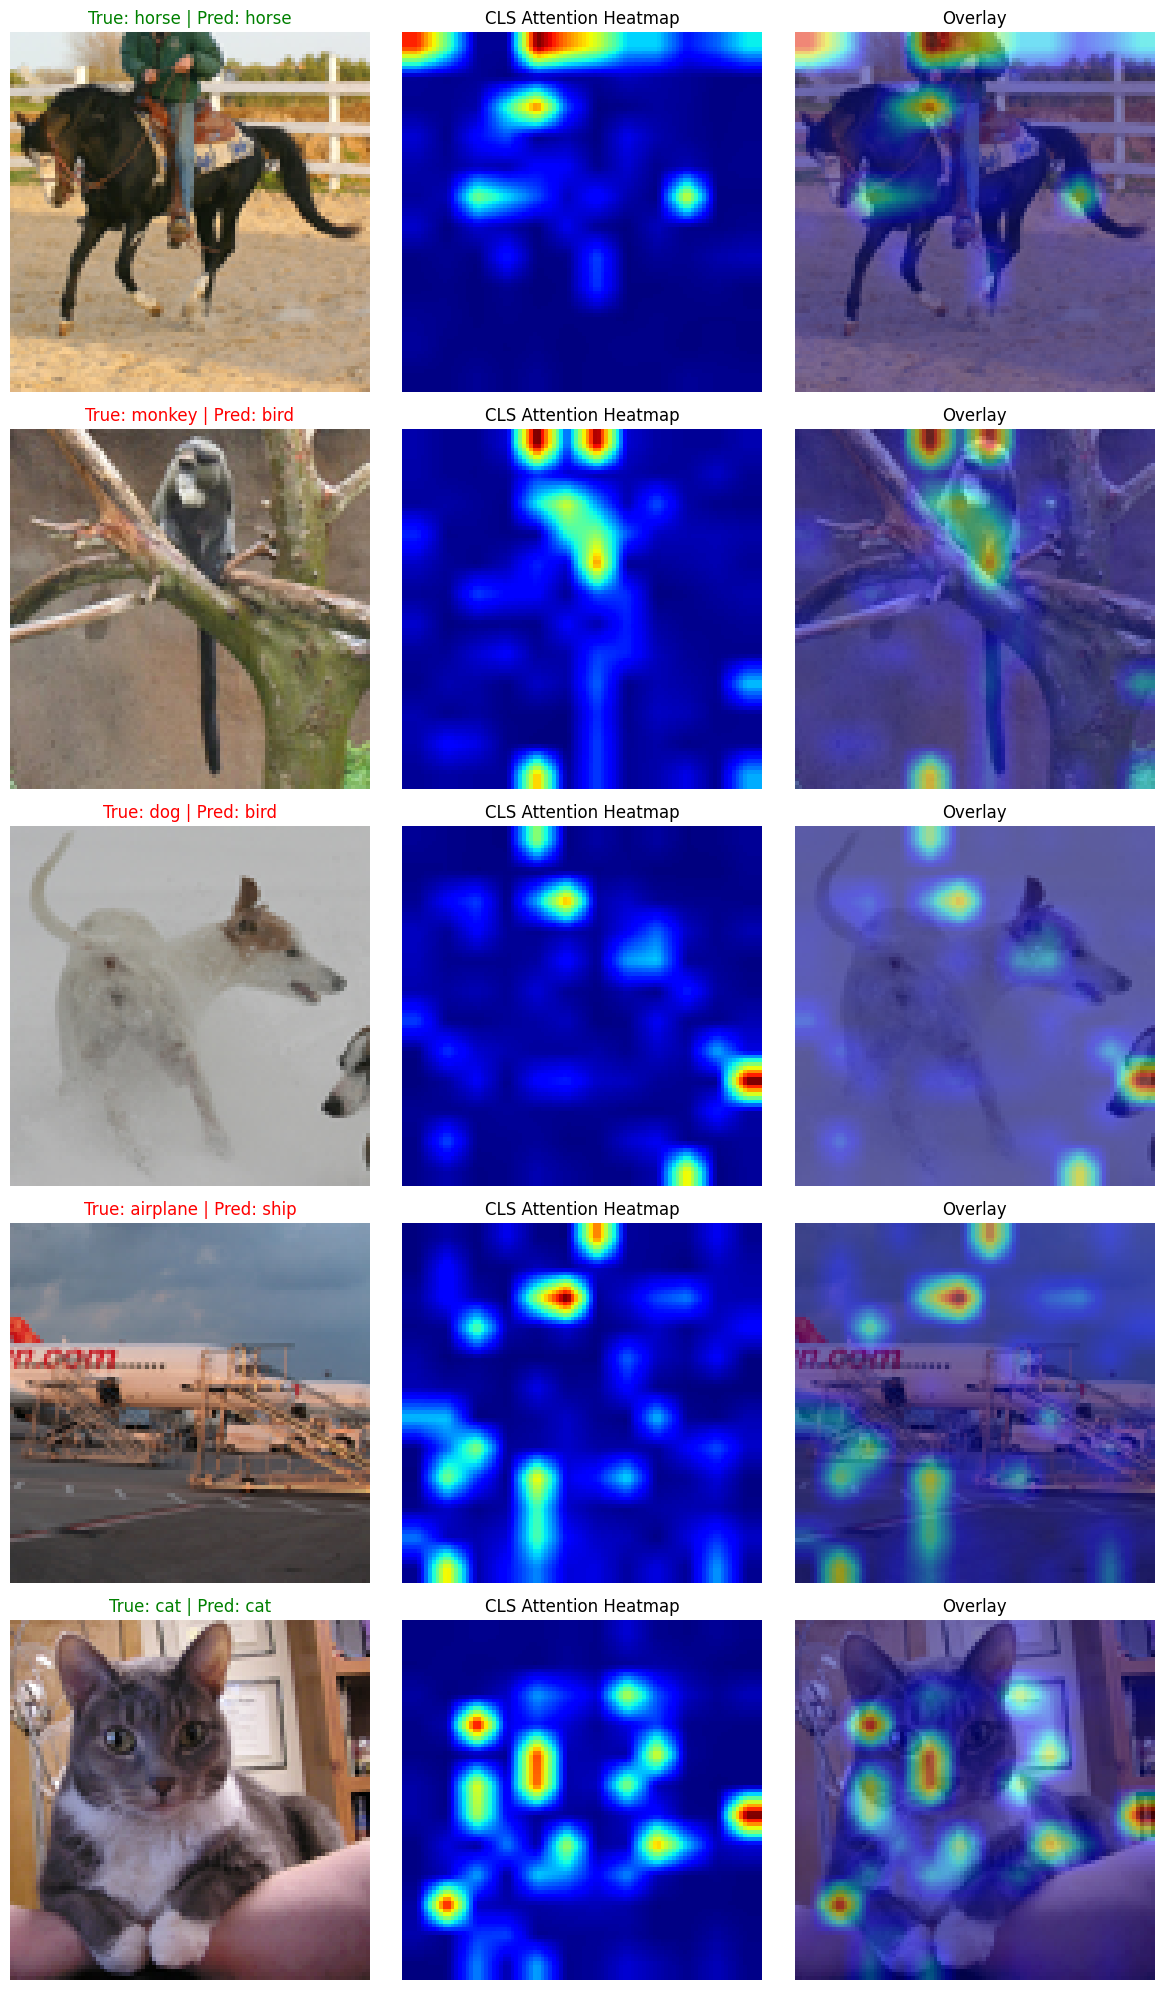

In [56]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def attention_visualizer(model, dataloader, num_images=5):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    
    with torch.inference_mode():
        preds, attn_weights = model(images)
    
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    
    for idx in range(num_images):
        img = images[idx].cpu().squeeze().permute(1,2,0) # Shape: [28, 28]
        img = img/2 + 0.5
        pred_label = torch.argmax(preds[idx]).item()
        true_label = labels[idx].item()
        
        last_layer_attn = attn_weights[idx, -1] # Shape: [12, 17, 17]
        avg_attn = last_layer_attn.mean(dim=0)  # Shape: [17, 17]
        
        # Isolate the CLS Token's perspective & reshape to 4x4
        cls_attn = avg_attn[0, 1:].reshape(12, 12) 
        
        # Upscale the 4x4 grid to 28x28
        cls_attn = cls_attn.unsqueeze(0).unsqueeze(0) 
        cls_attn = F.interpolate(cls_attn, size=(96, 96), mode='bilinear', align_corners=False)
        cls_attn = cls_attn.squeeze().cpu().numpy() 
        
        ax_orig = axes[idx, 0]
        ax_heat = axes[idx, 1]
        ax_over = axes[idx, 2]
        
        # Image 1: Original
        ax_orig.imshow(img, cmap='gray')
        color = "green" if true_label==pred_label else "red"
        ax_orig.set_title(f"True: {classes[true_label]} | Pred: {classes[pred_label]}", color=color)
        ax_orig.axis('off')
        
        # Image 2: Heatmap
        ax_heat.imshow(cls_attn, cmap='jet')
        ax_heat.set_title("CLS Attention Heatmap")
        ax_heat.axis('off')
        # Image 3: Overlay
        ax_over.imshow(img)
        ax_over.imshow(cls_attn, cmap='jet', alpha=0.5) 
        ax_over.set_title("Overlay")
        ax_over.axis('off')
        
    plt.tight_layout()
    plt.show()

model = model.to(DEVICE)
attention_visualizer(model, test_dataloader, num_images=5)

In [ ]:
from torchinfo import summary

batch_size = 32
summary(model, input_size=(batch_size, 3, 96, 96))

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [32, 10]                  --
├─Encoder: 1-1                                [32, 145, 384]            384
│    └─Conv2d: 2-1                            [32, 384, 12, 12]         74,112
│    └─LearnablePositionalEncoding: 2-2       [32, 145, 384]            55,680
│    │    └─Dropout: 3-1                      [32, 145, 384]            --
│    └─ModuleList: 2-3                        --                        --
│    │    └─EncoderBlock: 3-2                 [32, 145, 384]            1,183,872
│    │    └─EncoderBlock: 3-3                 [32, 145, 384]            1,183,872
│    │    └─EncoderBlock: 3-4                 [32, 145, 384]            1,183,872
│    │    └─EncoderBlock: 3-5                 [32, 145, 384]            1,183,872
├─Linear: 1-2                                 [32, 10]                  3,850
Total params: 4,869,514
Trainable params: 4,869,514
Non